In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from baseline_cox import SA
from utils import concordance_index, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [16]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [33]:
config_path = '../configs/config_tasks.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [34]:
task_id = config['dataset_kwargs']['task_id']
task_id

11

In [35]:
# %%time
# agent.old_integrated_brier_score(xs[:, 0], ts, cs)

In [36]:
# %%time
# agent.integrated_brier_score(xs[:, 0], ts, cs)

In [ ]:
%%time

num_exps = 5
sizes = [.2]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        res2_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        res3_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        res2_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.
.
.
.

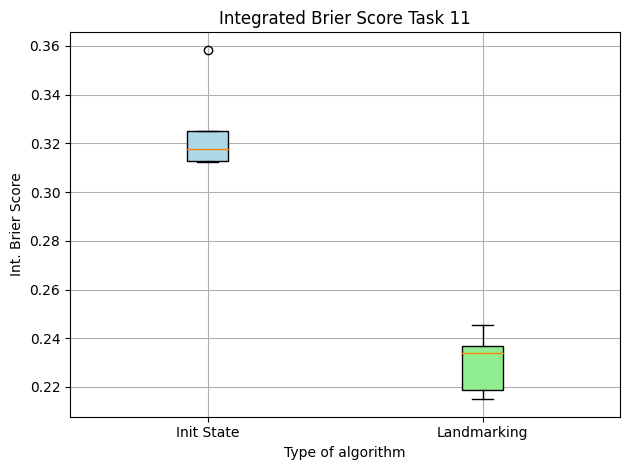

In [31]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

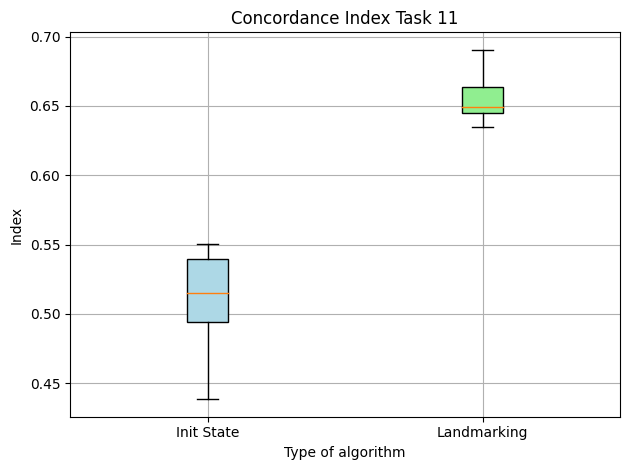

In [32]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [20]:
# Initial state.
config['landmark'] = False
model = SA(config, seed=0)

train_gen, test_gen = model.get_train_test(test_size=.2)
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs

tr_loss, te_loss = model.train(train_gen, test_gen)

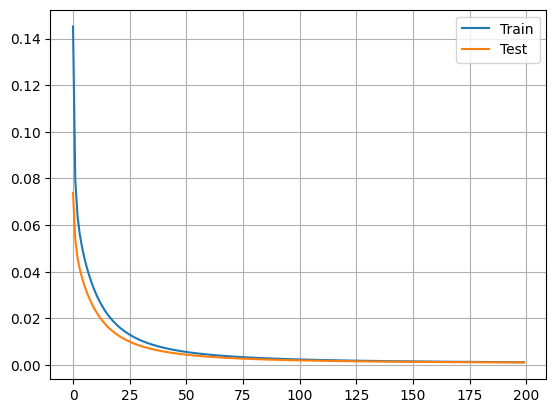

In [21]:
plt.plot(tr_loss, label='Train')
plt.plot(te_loss, label='Test')
plt.legend()
plt.grid()
plt.show()

In [22]:
surv = model.survival_curve(seqs)
print('IBS ', model.integrated_brier_score(surv[:,0], ts, cs))

IBS  0.31253102


In [28]:
scores = model.scores(jnp.expand_dims(seqs[:,0], axis=1)).squeeze()
print('CI: ', concordance_index(scores, ts, cs))

CI:  0.5507095880927657


In [24]:
model.state.params.keys()

dict_keys(['cox_linear_model'])

In [25]:
backbone_params = {key: value for key, value in model.state.params.items() if 'tcn_scores' in key}

In [26]:
backbone_params.keys()

dict_keys([])

In [29]:
beta = model.state.params['cox_linear_model']['beta']
scores = score(beta, seqs[:,0])
print('CI: ', concordance_index(scores, ts, cs))

CI:  0.5507095880927657


In [ ]:

# Landmarking.
config['landmark'] = True
model = SA(config, seed=fold)

train_gen, test_gen = model.get_train_test(test_size=size)
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs
ms = test_gen.mask

_ = model.train(train_gen, test_gen)
surv = model.survival_curve(seqs)
res2_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
beta = model.state.params['cox_linear_model']['beta']
seqs_ = seqs.reshape(-1, seqs.shape[-1])
scores = score(beta, seqs[:,0])
res3_lm[fold, i] = concordance_index(scores, ts, cs)